In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# STEP 1 — Loading Data

In [70]:
df = pd.read_csv("/content/ai4i2020.csv")

**The AI4I 2020 Predictive Maintenance dataset contains 10,000 observations and provides sensor-based measurements relevant to machine failure prediction. This makes it suitable for a supervised binary classification task.**


# STEP 2 — Initial Data Inspection/Preparation.


Scanning for duplicates

In [71]:
df.duplicated().sum()

np.int64(0)

**Scanning for class balance bold text**

In [72]:
df["Machine failure"].value_counts()

,count
Machine failure,
0,9661
1,339


**The target variable is imbalanced: machine failures are much less frequent than normal operating cases. This is important because accuracy alone may overstate model performance.**

**No duplicate rows were detected, suggesting that the dataset is already well structured for modeling.**

# STEP 3 — Removing Leakage Variables -




In [73]:
df = df.drop(columns=["TWF","HDF","PWF","OSF","RNF"])

**The failure-type columns (TWF, HDF, PWF, OSF, RNF) were removed because they directly reveal the reason for failure and would introduce target leakage.**


# STEP 4 — Remove identifier Columns, identify and remove missing data, check for outliers

In [74]:
df = df.drop(columns=["UDI","Product ID"])

In [75]:
# Calculate Q1, Q3, and IQR for numerical columns
Q1 = df.select_dtypes(include=np.number).quantile(0.25)
Q3 = df.select_dtypes(include=np.number).quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers for each numerical column
# A row is considered an outlier if any of its numerical features fall outside the IQR bounds
outliers = ((df.select_dtypes(include=np.number) < lower_bound) | (df.select_dtypes(include=np.number) > upper_bound)).any(axis=1)
outliers.sum()

np.int64(726)

**Ordinarily , one would be tempted to remove outliers in other to generate a more balance /accurate prediction model, however it is outliers like these that constitute equipment failure. Removing them from a dataset such as these this would be counter intuitive. **

# STEP 5 — Encode Categorical Variables and Rename them


This basically involves hot encoding the data.

In [76]:
if 'Type' in df.columns:
    df = pd.get_dummies(df, columns=["Type"], dtype=int)
else:
    print("'Type' column not found, assuming it has already been processed.")

In [28]:
df = df.rename(columns={
    "Type_L": "Low_Quality_Machine",
    "Type_M": "Medium_Quality_Machine",
    "Type_H": "High_Quality_Machine"
})

## STEP 6 — Feature Engineering. This helps to increase the features to 20 (in compliance with project rules)

In [77]:
# Physical relationships
df["Power"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]
df["Temp_Diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["Strain_Index"] = df["Torque [Nm]"] * df["Tool wear [min]"]

# Polynomial features
df["Torque2"] = df["Torque [Nm]"] ** 2
df["Speed2"] = df["Rotational speed [rpm]"] ** 2
df["Tool_Wear2"] = df["Tool wear [min]"] ** 2
df["Air_Temp2"] = df["Air temperature [K]"] ** 2
df["Process_Temp2"] = df["Process temperature [K]"] ** 2

# Interaction features
df["Torque_Air_Temp"] = df["Torque [Nm]"] * df["Air temperature [K]"]
df["Speed_Air_Temp"] = df["Rotational speed [rpm]"] * df["Air temperature [K]"]
df["Torque_Process_Temp"] = df["Torque [Nm]"] * df["Process temperature [K]"]
df["Tool_Wear_Speed"] = df["Tool wear [min]"] * df["Rotational speed [rpm]"]

Final Feature List (20 Total)

1–5. Raw Sensor Features
	1.	Air_Temperature
	2.	Process_Temperature
	3.	Rotational_Speed
	4.	Torque
	5.	Tool_Wear

⸻

6–8. Machine Type (One-Hot Encoded)
	6.	MachineType_Low
	7.	MachineType_Medium
	8.	MachineType_High

⸻

9–11. Physical Relationship Features
	9.	Power = Torque × Rotational_Speed
	10.	Temp_Diff = Process_Temperature − Air_Temperature
	11.	Strain_Index = Torque × Tool_Wear

⸻

12–16. Polynomial Features
	12.	Torque²
	13.	Speed²
	14.	Tool_Wear²
	15.	Air_Temperature²
	16.	Process_Temperature²

⸻

17–20. Interaction Features
	17.	Torque × Air_Temperature
	18.	Speed × Air_Temperature
	19.	Torque × Process_Temperature
	20.	Tool_Wear × Rotational_Speed

# STEP 7 —  Verifying Feature And Target Count

Here we check how many columns we now have.







In [78]:
df.columns
df.shape


(10000, 21)

STEP 8 — Separating Features and Target

Finally, we have

Total input features = 20 (listed above)

Target variable = Machine_Failure.



Also ,

 X = features and,

y = prediction target

In [79]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]



Verifying the Columns Used as Features and Confirming the Target Variable

In [80]:
print(X.head())
print(y.head())
print(X.shape)
print(y.shape)

   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Type_H  Type_L  Type_M    Power  Temp_Diff  \
0         42.8                0       0       0       1  66382.8       10.5   
1         46.3                3       0       1       0  65190.4       10.5   
2         49.4                5       0       1       0  74001.2       10.4   
3         39.5                7       0       1       0  56603.5       10.4   
4         40.0                9       0       1       0  56320.0       10.5   

   Strain_Index  Torque2   Speed2  Tool_Wear2  Air_Temp2  Process_Temp2  \

# STEP 9     Train/Test Split (80-20)

In [81]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Checking the shape and sizes of the split

In [82]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining data sample:")
print(X_train.head())

print("\nTest data sample:")
print(X_test.head())

X_train shape: (8000, 20)
X_test shape: (2000, 20)
y_train shape: (8000,)
y_test shape: (2000,)

Training data sample:
      Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
4058                302.0                    310.9                    1456   
1221                297.0                    308.3                    1399   
6895                301.0                    311.6                    1357   
9863                298.9                    309.8                    1411   
8711                297.1                    308.5                    1733   

      Torque [Nm]  Tool wear [min]  Type_H  Type_L  Type_M    Power  \
4058         47.2               54       0       0       1  68723.2   
1221         46.4              132       0       0       1  64913.6   
6895         45.6              137       0       0       1  61879.2   
9863         56.3               84       0       1       0  79439.3   
8711         28.7               50       0       1       

# Step 10 — Scaling, Fittting and Transforming the Training Data

In [83]:
scaler = StandardScaler()

In [84]:
X_train_scaled = scaler.fit_transform(X_train)

Transforming the Test Data

In [85]:
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled[:5])

[[ 0.99891359  0.60428162 -0.46060741  0.71830476 -0.84399726 -0.33078115
  -1.23436595  1.53620728  0.85238725 -1.10084184 -0.62194451  0.64817607
  -0.45000139 -0.88860632  0.99849741  0.60271845  0.74958299 -0.4058805
   0.73193829 -0.86687388]
 [-1.50519408 -1.15325984 -0.77557391  0.63845583  0.38226308 -0.33078115
  -1.23436595  1.53620728  0.48036335  1.29965826  0.64614014  0.55611208
  -0.70928637  0.12442682 -1.50036788 -1.15237982  0.59204694 -0.85024423
   0.61301902  0.18769155]
 [ 0.49809206  1.07746586 -1.00765448  0.5586069   0.46086951 -0.33078115
  -1.23436595  1.53620728  0.18404108  0.5995124   0.68954438  0.46562183
  -0.89371354  0.21834256  0.49538697  1.07776322  0.57368547 -0.97957576
   0.58205931  0.2000328 ]
 [-0.55363316 -0.13929361 -0.70926517  1.62658635 -0.37235867 -0.33078115
   0.81013252 -0.65095382  1.89886071  0.89957491  0.1512467   1.80616851
  -0.65556044 -0.59952739 -0.55571336 -0.14162192  1.60567631 -0.73561715
   1.6228863  -0.47008424]
 [-1.

# Step 11— Training the Models

Logistic Regression

In [86]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

 kNN

In [87]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

#     Step 12 —Evaluation the models

In [88]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

In [89]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\nk-Nearest Neighbors Results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Logistic Regression Results
Accuracy: 0.9695
[[1921   11]
 [  50   18]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1932
           1       0.62      0.26      0.37        68

    accuracy                           0.97      2000
   macro avg       0.80      0.63      0.68      2000
weighted avg       0.96      0.97      0.96      2000


k-Nearest Neighbors Results
Accuracy: 0.9755
[[1927    5]
 [  44   24]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.83      0.35      0.49        68

    accuracy                           0.98      2000
   macro avg       0.90      0.68      0.74      2000
weighted avg       0.97      0.98      0.97      2000



# Step 13 — Hyperparameter Tuning

Tuning Logistic Regression

In [90]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000),
                       param_grid_lr,
                       cv=5)

grid_lr.fit(X_train_scaled, y_train)

print("Best Logistic Regression parameter:", grid_lr.best_params_)

Best Logistic Regression parameter: {'C': 100}


Tuning k-Nearest Neighbors

In [91]:
param_grid_knn = {'n_neighbors': [3,5,7,9,11]}

grid_knn = GridSearchCV(KNeighborsClassifier(),
                        param_grid_knn,
                        cv=5)

grid_knn.fit(X_train_scaled, y_train)

print("Best k value:", grid_knn.best_params_)

Best k value: {'n_neighbors': 9}


# Step 14- Comparing tuned vs baseline models

In [92]:
best_lr = grid_lr.best_estimator_
best_knn = grid_knn.best_estimator_

In [93]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {'C':[0.01,0.1,1,10,100]}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000),
                       param_grid_lr,
                       cv=5)

grid_lr.fit(X_train_scaled,y_train)

best_lr = grid_lr.best_estimator_

In [94]:
param_grid_knn = {'n_neighbors':[3,5,7,9,11]}

grid_knn = GridSearchCV(KNeighborsClassifier(),
                        param_grid_knn,
                        cv=5)

grid_knn.fit(X_train_scaled,y_train)

best_knn = grid_knn.best_estimator_

In [95]:
param_grid_knn = {'n_neighbors':[3,5,7,9,11]}

grid_knn = GridSearchCV(KNeighborsClassifier(),
                        param_grid_knn,
                        cv=5)

grid_knn.fit(X_train_scaled,y_train)

best_knn = grid_knn.best_estimator_

In [96]:
print("Baseline Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr.predict(X_test_scaled)))
print("F1 Score:", f1_score(y_test, lr.predict(X_test_scaled)))

print("\nTuned Logistic Regression")
print("Accuracy:", accuracy_score(y_test, best_lr.predict(X_test_scaled)))
print("F1 Score:", f1_score(y_test, best_lr.predict(X_test_scaled)))

print("\nBaseline kNN")
print("Accuracy:", accuracy_score(y_test, knn.predict(X_test_scaled)))
print("F1 Score:", f1_score(y_test, knn.predict(X_test_scaled)))

print("\nTuned kNN")
print("Accuracy:", accuracy_score(y_test, best_knn.predict(X_test_scaled)))
print("F1 Score:", f1_score(y_test, best_knn.predict(X_test_scaled)))

Baseline Logistic Regression
Accuracy: 0.9695
F1 Score: 0.3711340206185567

Tuned Logistic Regression
Accuracy: 0.9705
F1 Score: 0.42718446601941745

Baseline kNN
Accuracy: 0.9755
F1 Score: 0.4948453608247423

Tuned kNN
Accuracy: 0.973
F1 Score: 0.41304347826086957


# Step 15- Confusion Matrix Heatmap

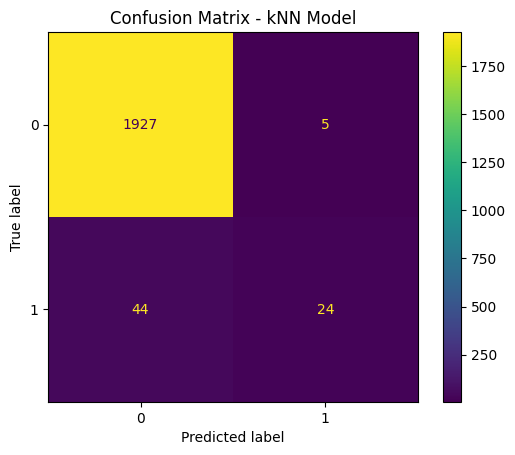

In [97]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict using best model (Baseline kNN)
y_pred = knn.predict(X_test_scaled)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - kNN Model")
plt.show()

# Step 16- ROC Curve

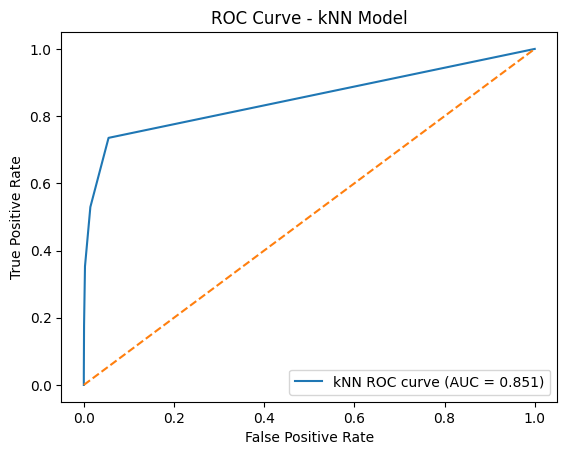

In [98]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction probabilities
y_prob = knn.predict_proba(X_test_scaled)[:,1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label="kNN ROC curve (AUC = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - kNN Model")
plt.legend(loc="lower right")
plt.show()

                          Model  Accuracy  F1 Score
0  Baseline Logistic Regression    0.9695  0.371134
1     Tuned Logistic Regression    0.9705  0.427184
2                  Baseline kNN    0.9755  0.494845
3                     Tuned kNN    0.9730  0.413043


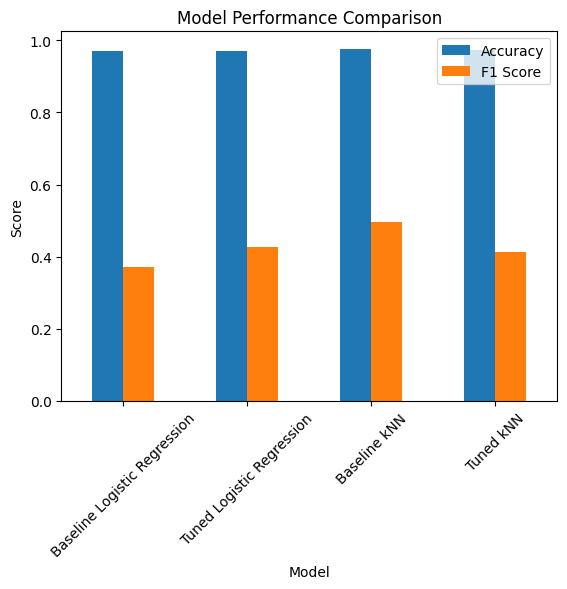

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

results = {
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression",
        "Baseline kNN",
        "Tuned kNN"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr.predict(X_test_scaled)),
        accuracy_score(y_test, best_lr.predict(X_test_scaled)),
        accuracy_score(y_test, knn.predict(X_test_scaled)),
        accuracy_score(y_test, best_knn.predict(X_test_scaled))
    ],

    "F1 Score": [
        f1_score(y_test, lr.predict(X_test_scaled)),
        f1_score(y_test, best_lr.predict(X_test_scaled)),
        f1_score(y_test, knn.predict(X_test_scaled)),
        f1_score(y_test, best_knn.predict(X_test_scaled))
    ]
}

results_df = pd.DataFrame(results)

print(results_df)

results_df.set_index("Model").plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

Both baseline models achieved high overall accuracy, exceeding 96%. However, because machine failures are relatively rare in the dataset, accuracy alone was not sufficient to evaluate model performance. The F1 score provided a more meaningful measure of how well the models identified failures while limiting false positives. Among the models tested, baseline k-Nearest Neighbors produced the highest F1 score (0.4948), making it the strongest model for this task. Logistic Regression improved modestly after tuning, while tuned kNN performed worse than the baseline kNN. This suggests that the tuning process may have favored overall accuracy rather than minority-class detection.

# Step 16- Conclusion


This project developed and evaluated machine learning models for predicting machine failure using the AI4I 2020 Predictive Maintenance dataset. After preprocessing the data, removing leakage and identifier variables, encoding categorical values, engineering additional features, and scaling the predictors, two models were trained and compared: Logistic Regression and k-Nearest Neighbors.

The results showed that all models achieved high overall accuracy, but the class imbalance in the dataset made F1 score a more informative metric for evaluation. Among the tested approaches, the baseline k-Nearest Neighbors model performed best, achieving the strongest balance between precision and recall. Logistic Regression improved slightly after tuning, while tuned kNN did not outperform its baseline version.

Overall, the project demonstrates that relatively simple machine learning methods can provide useful predictive performance for sensor-based maintenance problems, especially when paired with careful preprocessing and feature engineering. At the same time, the results highlight the challenge of detecting rare failure events and suggest that future work could explore class-balancing strategies, threshold adjustment, or alternative models to further improve failure detection.